In [ ]:
import pandas as pd
df = pd.read_csv('/content/dataset.csv')
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


Columns: Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


=== Evaluation Metrics ===
Accuracy : 95.0 %
Precision: 1.0
Recall   : 0.95
F1 Score : 0.9666666666666666

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         0
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           0.95        20
   macro avg       0.86      0.79      0.81        20
weighted avg       1.00      0.95      0.97        20



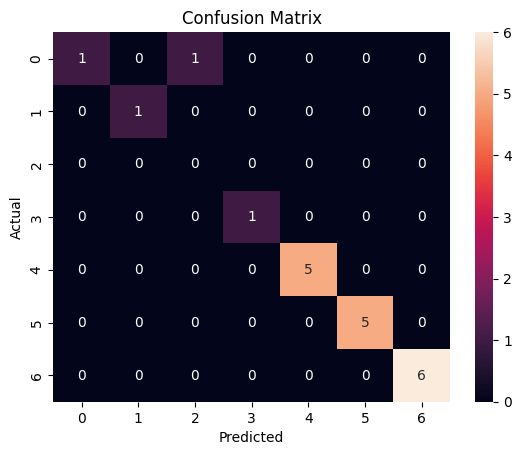

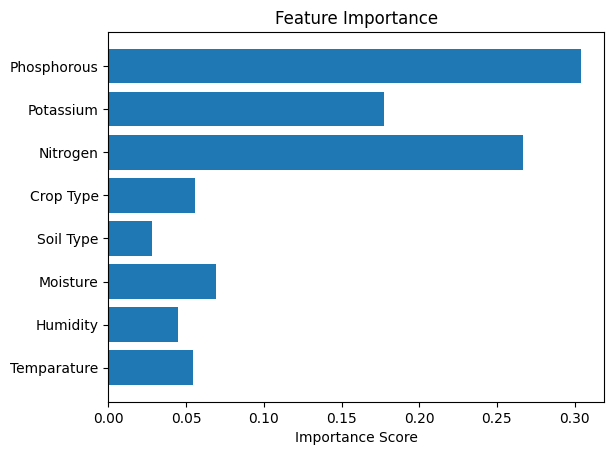

✅ Model & encoders saved


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

# Load dataset
data = pd.read_csv('/content/dataset.csv')

# 🔥 CLEAN COLUMN NAMES
data.columns = data.columns.str.strip()

print("Columns:", data.columns)

# Encode categorical columns
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()

data['Soil Type'] = le_soil.fit_transform(data['Soil Type'])
data['Crop Type'] = le_crop.fit_transform(data['Crop Type'])
data['Fertilizer Name'] = le_fert.fit_transform(data['Fertilizer Name'])

# Features (INPUT)
X = data[['Temparature', 'Humidity', 'Moisture',
          'Soil Type', 'Crop Type',
          'Nitrogen', 'Potassium', 'Phosphorous']]

# Target (OUTPUT)
y = data['Fertilizer Name']

# ✅ TRAIN-TEST SPLIT (IMPORTANT ADDITION)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

# Prediction on test data
y_pred = model.predict(X_test)

# ==============================
# ✅ EVALUATION METRICS
# ==============================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n=== Evaluation Metrics ===")
print("Accuracy :", accuracy * 100, "%")
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# ==============================
# ✅ CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# ✅ FEATURE IMPORTANCE
# ==============================

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# ==============================
# ✅ SAVE MODEL (UNCHANGED)
# ==============================

joblib.dump(model, "model.pkl")
joblib.dump(le_soil, "soil_encoder.pkl")
joblib.dump(le_crop, "crop_encoder.pkl")
joblib.dump(le_fert, "fert_encoder.pkl")

print("✅ Model & encoders saved")